In [1]:
import json
import pandas as pd

results = json.load(open('eval_results.json'))
report = json.load(open('experiment_report.json'))

## Per-Sample Predictions

In [2]:
df = pd.DataFrame(results['samples'])
df['filename'] = df['filepath'].apply(lambda p: p.split('/')[-1])
df['correct'] = df['ground_truth'] == df['pegasus_label']
df[['filename', 'ground_truth', 'pegasus_label', 'correct', 'embedding_dim']]

,filename,ground_truth,pegasus_label,correct,embedding_dim
0,5_te8.mp4,Authorized Intervention,ERROR,False,512
1,5_te12.mp4,Authorized Intervention,ERROR,False,512
2,5_te6.mp4,Authorized Intervention,ERROR,False,512
3,5_te4.mp4,Authorized Intervention,ERROR,False,512
4,5_te7.mp4,Authorized Intervention,ERROR,False,512
...,...,...,...,...,...
67,1_te7.mp4,Unauthorized Intervention,NaN,False,0
68,1_te1.mp4,Unauthorized Intervention,NaN,False,0
69,1_te9.mp4,Unauthorized Intervention,NaN,False,0
70,1_te3.mp4,Unauthorized Intervention,NaN,False,0


## Metrics Summary

In [3]:
pd.DataFrame([results['metrics']]).T.rename(columns={0: 'value'})

,value
embedding_knn_accuracy,0.498775
embedding_binary_accuracy,0.64
embedding_silhouette,0.024136
retrieval_map_at_5,0.425833
retrieval_recall_at_5,0.195415
retrieval_per_query,{'person walking outside the safe walkway boun...
generation_accuracy,0.2
generation_binary_accuracy,0.3
generation_format_compliance,0.4
generation_hallucination_rate,0.6


## Retrieval Per-Query Breakdown

In [4]:
retrieval = report['results']['benchmark_b_retrieval_quality']['per_query']
rdf = pd.DataFrame([
    {'query': q, 'expected': ', '.join(v['expected']), 'AP@5': v['ap'], 'Recall@5': v['recall']}
    for q, v in retrieval.items()
]).sort_values('AP@5', ascending=False)
rdf

,query,expected,AP@5,Recall@5
7,forklift safely transporting a normal load,Safe Carrying,1.00,0.83
5,authorized maintenance worker servicing equipment,Authorized Intervention,0.89,0.40
9,proper safety protocol being followed,all safe labels,0.89,0.15
2,electrical panel left open and unattended,Opened Panel Cover,0.83,0.20
3,forklift carrying too many items stacked dange...,Carrying Overload with Forklift,0.33,0.29
8,safety violation on the factory floor,all unsafe labels,0.33,0.09
0,person walking outside the safe walkway boundary,Safe Walkway Violation,0.00,0.00
1,worker stepping into restricted area without a...,Unauthorized Intervention,0.00,0.00
4,worker walking within the designated safe path,Safe Walkway,0.00,0.00
6,panel cover properly closed and secured,Closed Panel Cover,0.00,0.00


## Pegasus Per-Class Breakdown

In [5]:
per_class = report['results']['benchmark_c_generation_quality']['per_class_results']
pcdf = pd.DataFrame(per_class).T
pcdf.index.name = 'class'
pcdf

,n,labeled,correct,note,predictions
class,,,,,
Authorized Intervention,10,0,0,All 10 failed due to rate limits,NaN
Carrying Overload with Forklift,7,0,0,All 7 failed due to rate limits,NaN
Closed Panel Cover,8,5,0,NaN,"{'Safe Walkway': 3, 'Unsafe': 2}"
Opened Panel Cover,10,10,0,NaN,"{'Unsafe': 9, 'Safe Walkway': 1}"
Safe Carrying,6,6,4,NaN,"{'Safe Carrying': 4, 'Unsafe': 2}"
Safe Walkway,3,3,2,NaN,"{'Safe Walkway': 2, 'Unsafe': 1}"
Safe Walkway Violation,3,3,0,NaN,"{'Safe Walkway': 2, 'Unsafe': 1}"
Unauthorized Intervention,3,3,0,NaN,"{'Unsafe': 2, 'SAFE': 1}"


## Pegasus Output Distribution

Matplotlib is building the font cache; this may take a moment.


<Axes: title={'center': 'Pegasus Output Distribution'}, ylabel='pegasus_label'>

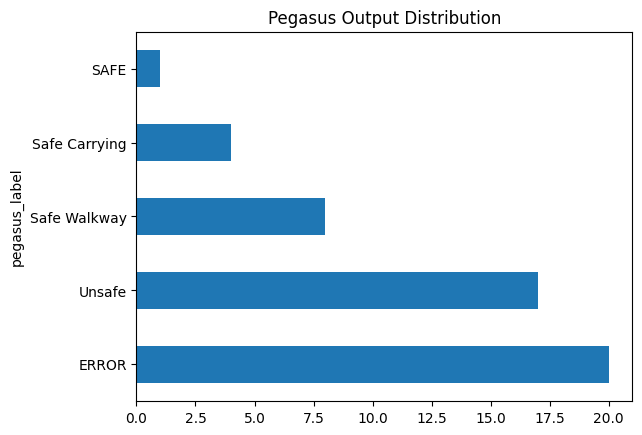

In [6]:
df['pegasus_label'].value_counts().plot.barh(title='Pegasus Output Distribution')

## Confusion: Ground Truth vs Pegasus

In [7]:
labeled = df[~df['pegasus_label'].isin(['ERROR', None])]
pd.crosstab(labeled['ground_truth'], labeled['pegasus_label'], margins=True)

pegasus_label,SAFE,Safe Carrying,Safe Walkway,Unsafe,All
ground_truth,,,,,
Closed Panel Cover,0,0,3,2,5
Opened Panel Cover,0,0,1,9,10
Safe Carrying,0,4,0,2,6
Safe Walkway,0,0,2,1,3
Safe Walkway Violation,0,0,2,1,3
Unauthorized Intervention,1,0,0,2,3
All,1,4,8,17,30
